# Missing data: a first investigation

In this practical, you will write short pieces of Python to compare a complete customer dataset with a copy containing missing values. Each exercise suggests useful functions, but you choose how to use them and how to present your observations.

If Python is new to you, work one cell at a time, run it with **Shift + Enter**, inspect the result, and answer the question in a Markdown cell.


In [1]:
%pip install missingno

  Using cached missingno-0.5.2-py3-none-any.whl.metadata (639 bytes)
  Using cached numpy-2.5.3-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.2-cp314-cp314-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached scipy-1.18.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.4.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
  Using cached pandas-3.0.6-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
Using cached missingno-0.5.2-py3-none-any.whl (8.7 kB)
Using cached matplotlib-3.11.2-cp314-cp314-macosx_11_0_arm64.whl (9.3 MB)
Using cached contourpy-1.4.0-cp314-cp3

## Setup — code provided

Run this cell first; you do not need to modify it. It imports the libraries and locates the data folder.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno

DATA_DIR = Path("data/missing_data")
if Path("Session1").is_dir():
    DATA_DIR = Path("Session1/data/missing_data")
pd.set_option("display.max_rows", 20)


## The data

Both files contain the same 1,020 users in the same order. `customers_complete.csv` is the original. In `customers.csv`, some values are blank. IDs and registration status are always present.

| Column | Meaning |
|---|---|
| `user_id` | Consecutive ID, from 1 to 1,020 |
| `age` | Age in years |
| `income` | Annual income in euros |
| `city` | City of residence |
| `is_registered_customer` | 0 = not registered, 1 = registered |


### 1.0 — Load and inspect the files

Load each CSV into a pandas DataFrame, then inspect a few rows. The later questions refer to the DataFrames as `original` and `incomplete`.

**Useful functions**

- `pd.read_csv(path)` loads a CSV file.
- `data.head()` returns the first five rows.
- `display(...)` shows a result neatly.

Example shape: `name = pd.read_csv(DATA_DIR / "file.csv")`


In [3]:
# Load and inspect the two files.
# Write your code here.
data = pd.read_csv("data/missing_data/customers.csv")
data_complete = pd.read_csv("data/missing_data/customers_complete.csv")
h=data.head()
display(h)

,user_id,age,income,city,is_registered_customer
0,1,40.0,NaN,Paris,1
1,2,43.6,62270.0,Paris,0
2,3,36.7,63926.0,Paris,0
3,4,29.3,28830.0,Lyon,1
4,5,34.5,37796.0,Lyon,0


### 1.1 — Count missing values

Find how many values are missing in each column of `incomplete`. You may also express the result as a fraction or percentage. Choose how you want to display your results.

**Useful functions**

- `data.isna()` returns `True` for every missing cell.
- `.sum()` counts the `True` values column by column.
- `.mean()` gives their fraction column by column.

**Question:** Which column has the most missing values?


In [4]:
# Investigate how much data is missing in each column.
# Write your code here.

# The column which contains the most missing values is city
print(data["is_registered_customer"].isna().sum())
print(data["city"].isna().sum())
print(data["income"].isna().sum())
print(data["age"].isna().sum())


0
108
99
69


### 1.2 — Summarise the numerical columns

Compare age and income in the complete and incomplete datasets. Decide which summary statistics are useful for your comparison.

**Useful functions**

- `data[["column1", "column2"]]` selects several columns.
- `.describe()` calculates count, mean, standard deviation, minimum, quartiles, and maximum.
- You can calculate one statistic directly with functions such as `.mean()` or `.median()`.

**Question:** Which numerical variable seems most affected by the missing values? Explain using one or more statistics.


In [5]:
# Compare the numerical columns in the complete and incomplete datasets.
# Write your code here.
#income is most affected
data[["age", "income"]].describe()

,age,income
count,951.000000,921.000000
mean,39.320084,44221.173724
std,11.141334,13563.336945
min,18.000000,12000.000000
25%,31.900000,35613.000000
50%,39.200000,45341.000000
75%,46.950000,54637.000000
max,70.900000,69798.000000


In [16]:
data_complete[["age", "income"]].describe()
data[["age", "income"]].describe() - data_complete[["age", "income"]].describe()

               age        income
count  1020.000000   1020.000000
mean     39.269020  46752.811765
std      11.021436  15660.604606
min      18.000000  12000.000000
25%      31.900000  36493.500000
50%      39.200000  46676.000000
75%      46.700000  57350.500000
max      70.900000  93667.000000


,age,income
count,-69.000000,-99.00000
mean,0.051065,-2531.63804
std,0.119898,-2097.26766
min,0.000000,0.00000
25%,0.000000,-880.50000
50%,0.000000,-1335.00000
75%,0.250000,-2713.50000
max,0.000000,-23869.00000


In [17]:
data_complete[["age", "income"]].describe()

,age,income
count,1020.000000,1020.000000
mean,39.269020,46752.811765
std,11.021436,15660.604606
min,18.000000,12000.000000
25%,31.900000,36493.500000
50%,39.200000,46676.000000
75%,46.700000,57350.500000
max,70.900000,93667.000000


In [18]:
data[["age", "income"]].describe() - data_complete[["age", "income"]].describe()

,age,income
count,-69.000000,-99.00000
mean,0.051065,-2531.63804
std,0.119898,-2097.26766
min,0.000000,0.00000
25%,0.000000,-880.50000
50%,0.000000,-1335.00000
75%,0.250000,-2713.50000
max,0.000000,-23869.00000


### 1.3 — See the missing values

Explore the missing values visually. In a missingness matrix, a white gap represents a missing value.

**Useful functions**

- `msno.bar(data)` counts the known values.
- `msno.matrix(data)` shows where values are missing.
- `data.sort_values("column")` may reveal a pattern when rows are reordered.
- `plt.show()` displays a plot.

**Question:** Can you spot rows where age, income, and city are all missing? Do you notice any other patterns?


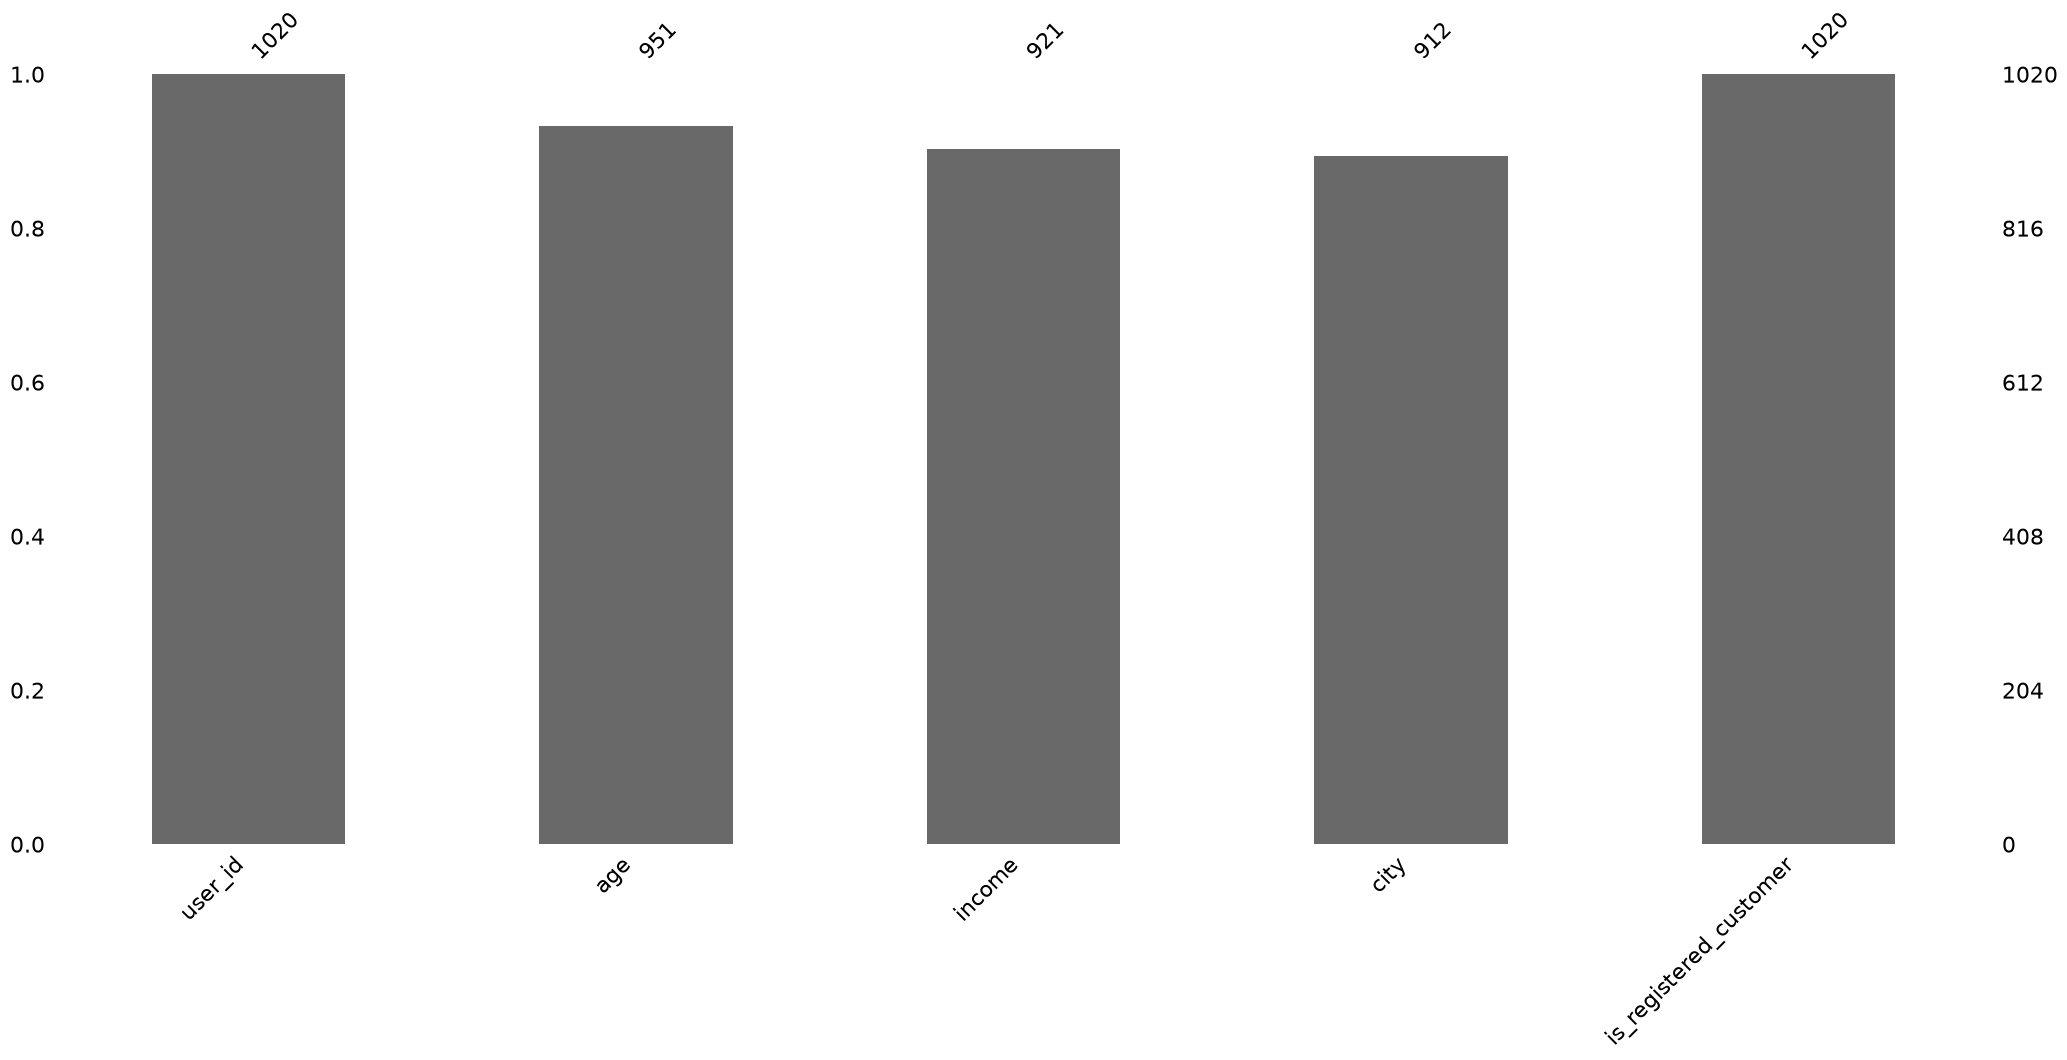

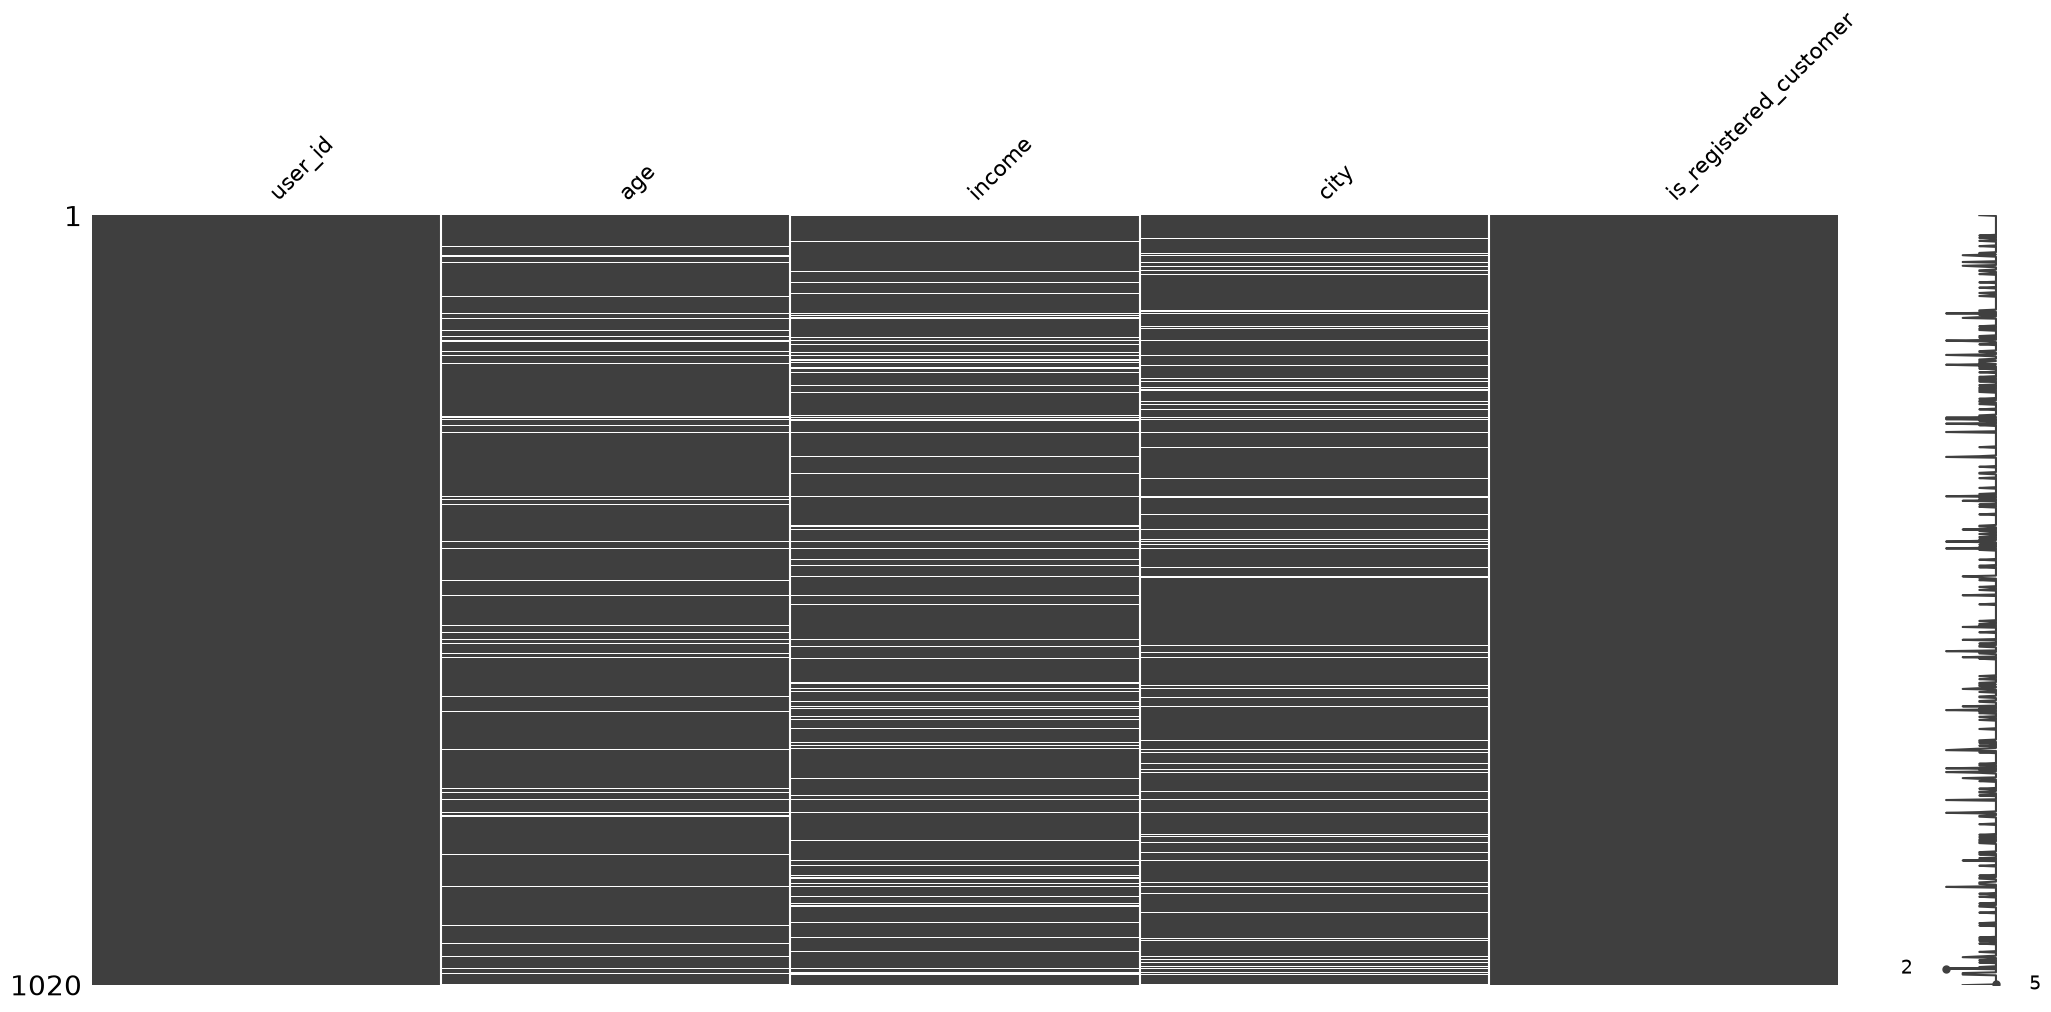

,user_id,age,income,city,is_registered_customer
757,758,35.5,37960.0,Bordeaux,0
224,225,39.3,37450.0,Bordeaux,0
219,220,21.8,16519.0,Bordeaux,0
821,822,31.4,40073.0,Bordeaux,1
819,820,36.6,20525.0,Bordeaux,0
...,...,...,...,...,...
995,996,29.2,41181.0,NaN,0
997,998,NaN,NaN,NaN,1
1003,1004,64.3,NaN,NaN,0
1005,1006,61.3,NaN,NaN,0


In [35]:
# Explore the locations and amounts of missing data visually.
# Write your code here.
msno.bar(data)
msno.matrix(data)
plt.show()

#data.sort_values("age")
data.sort_values("city")
#data.sort_values("income")

### 1.4 — Compare distributions

Compare the distributions of age, income, and city between the complete and incomplete datasets. Choose tables or plots that make the differences clear.

**Useful functions for numerical variables**

- `series.plot.hist(...)` makes a histogram. Useful options include `bins=`, `density=True`, `alpha=0.5`, and `label=`.
- `np.linspace(minimum, maximum, 25)` can create shared bin edges for two histograms.
- `series.min()` and `series.max()` find the limits.
- calling twice the plot.hist function and then `plt.show()` allow to superpose two histograms to compare them

**Useful functions for categorical variables**

- `series.value_counts()` counts each category.
- `series.value_counts(normalize=True) * 100` calculates percentages.
- `.plot.bar(rot=0)` makes a bar chart.

**Question:** Which distribution changes most visibly? Why might this happen?


<Axes: ylabel='Frequency'>

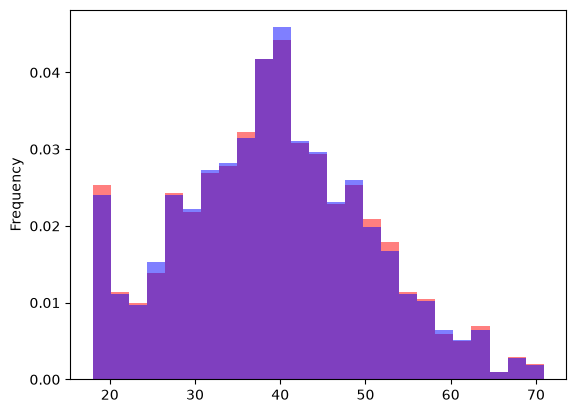

In [17]:
# Compare the distributions. Add more code cells if useful.
# Write your code here.
#help(data.plot)
data["age"].plot.hist( bins=25, density=True, alpha=0.5, label=True, color="red")
data_complete["age"].plot.hist( bins=25, density=True, alpha=0.5, label=True, color="blue")
#data["income"].plot.hist( bins=25, density=True, alpha=0.5, label=True)
#data["city"].plot.hist( bins=25, density=True, alpha=0.5, label=True)
#type(data["age"])
#help(pd.Series.plot.hist)

### 1.5 — Missingness by customer status

Check whether age and city are missing equally often for registered and unregistered users. Choose how to calculate and present the comparison. Python treats `True` as 1 and `False` as 0, so a group mean is the missing fraction.

**Useful functions**

- `data["column"].isna()` marks missing values.
- `data[["column"]].copy()` can start a separate working table if you want one.
- `data.groupby("is_registered_customer").mean()` calculates means for each group.
- `.plot.bar(rot=0)` can display a comparison chart.

**Question:** Which variable is missing more often for unregistered users?


<Axes: >

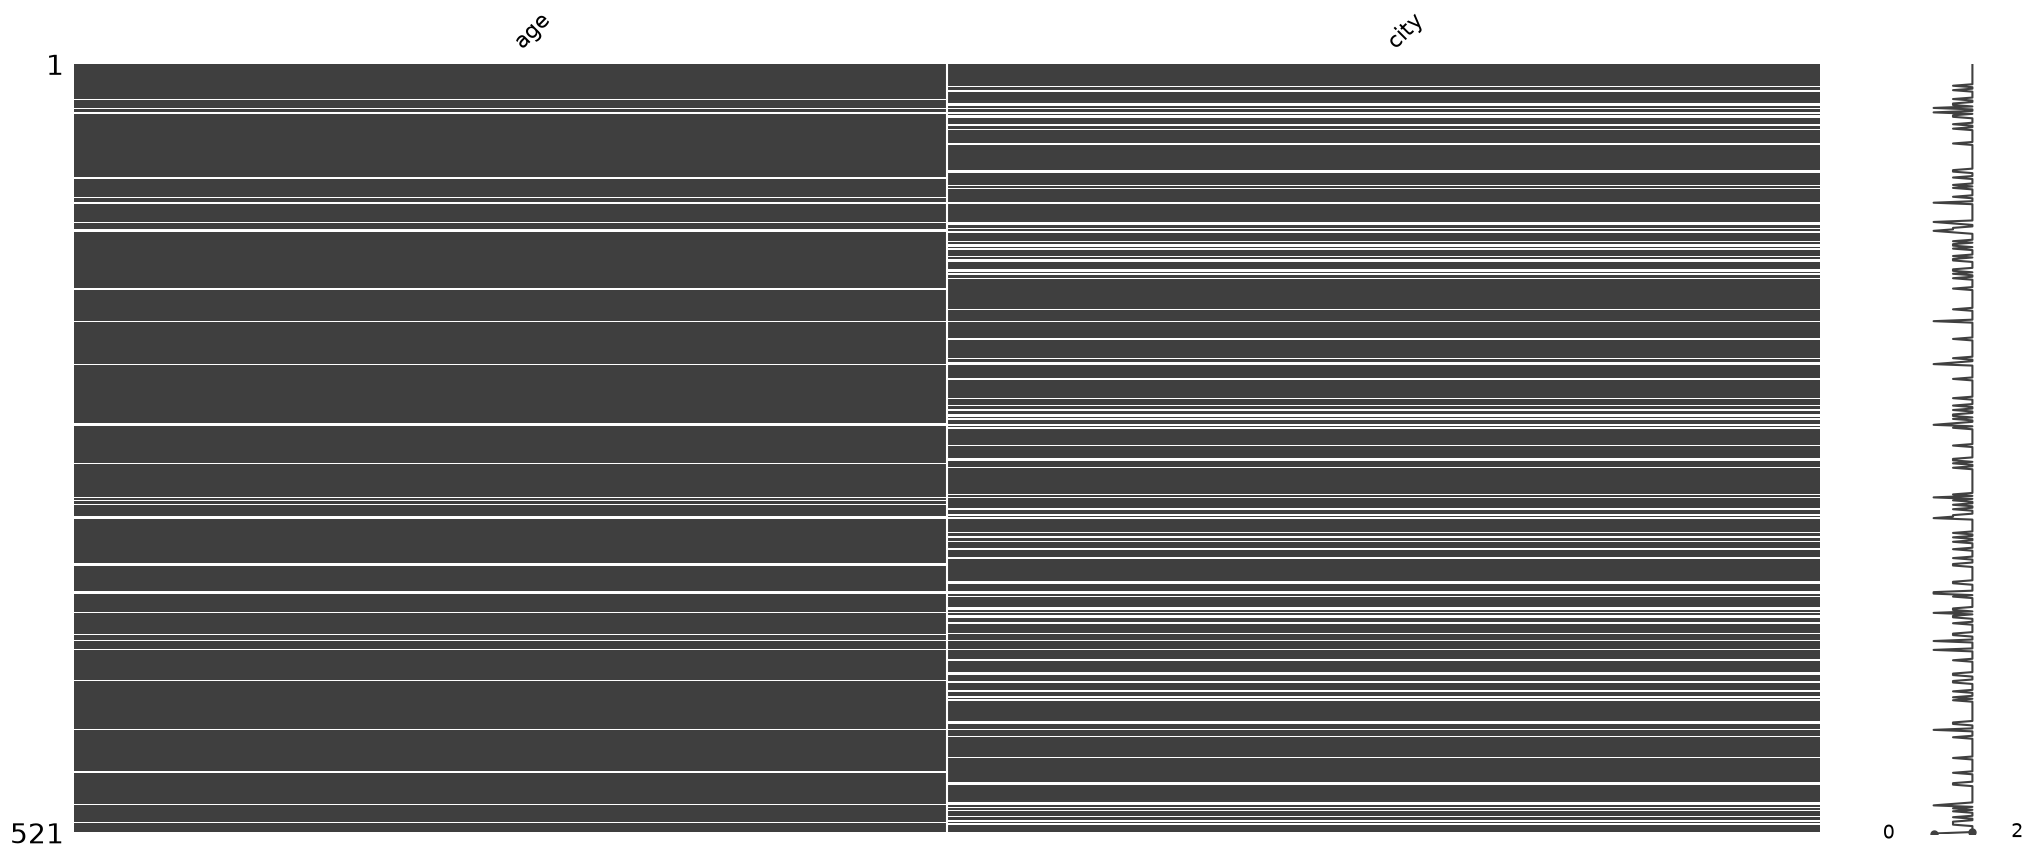

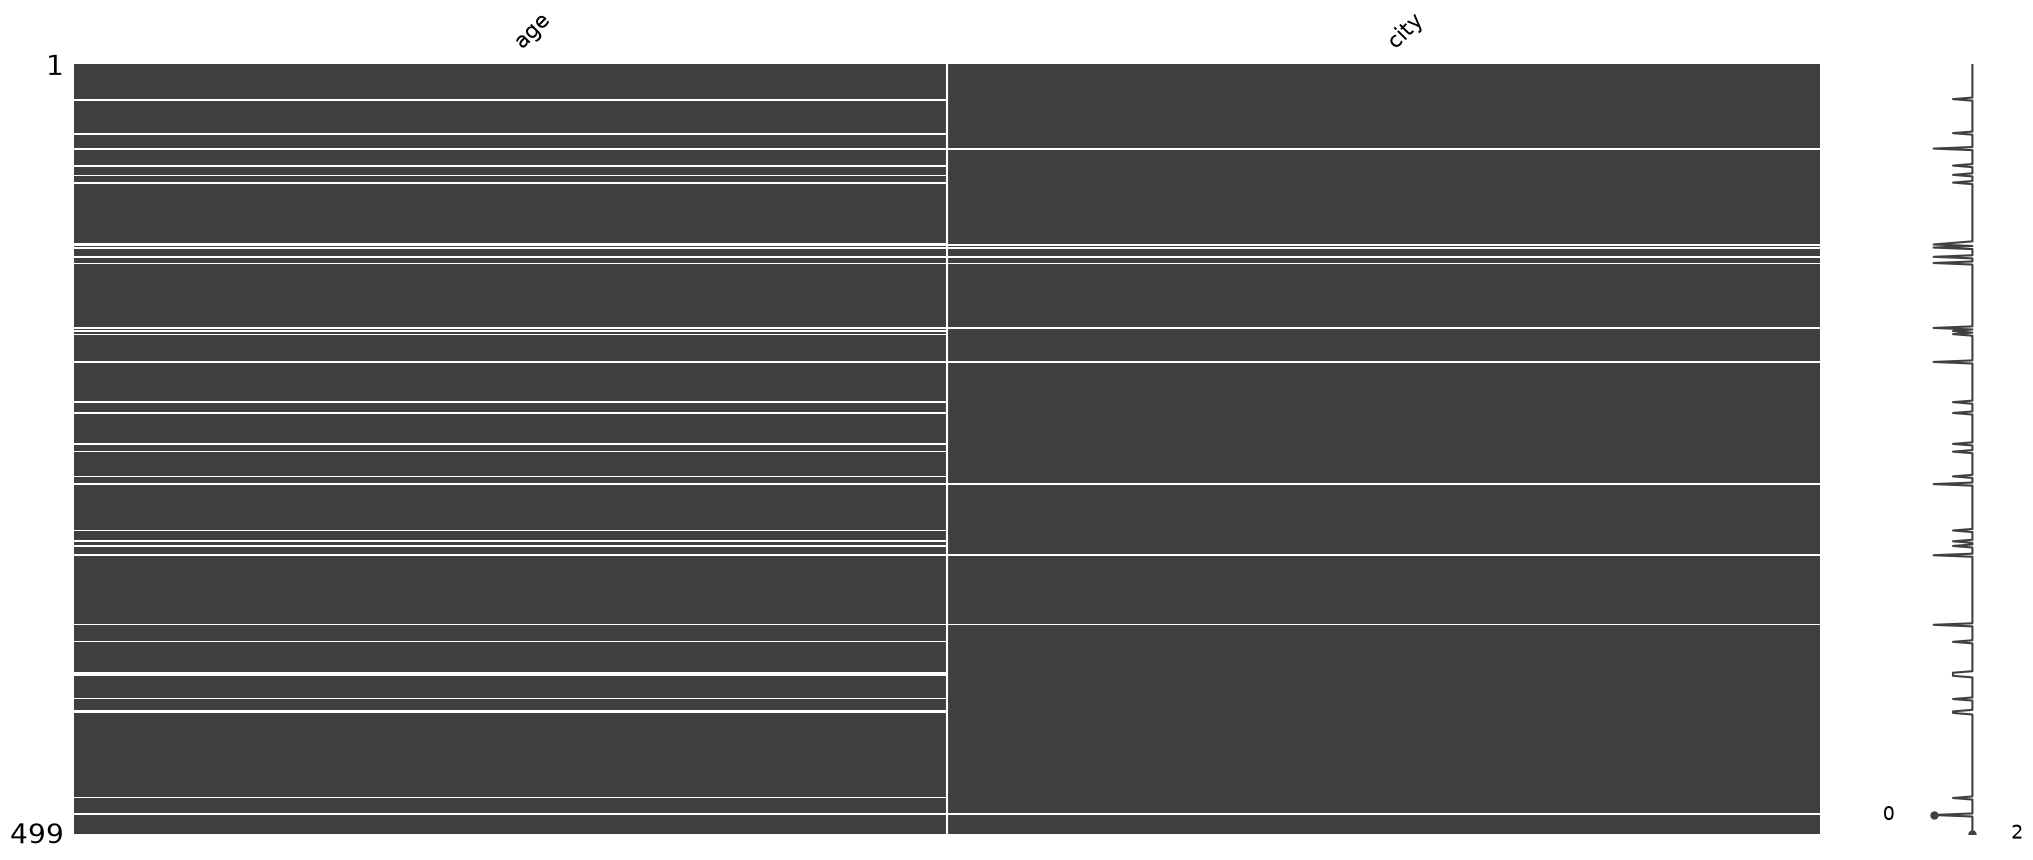

In [18]:
# Compare missingness between registered and unregistered customers.
# Write your code here.
not_reg = data.loc[
    data["is_registered_customer"] == 0,
    ["age", "city"]
]
reg = data.loc[
    data["is_registered_customer"] == 1,
    ["age", "city"]
]
# not_reg["age"].plot.bar(rot=0, color="red")
# reg["age"].plot.bar(rot=0, color="green")
msno.matrix(not_reg)
msno.matrix(reg)

### 1.6 — Interpret carefully

Look again at the income distributions.

**Question:** Could the incomplete data alone tell you that high incomes had been removed? Explain what you can observe and what you cannot know from the incomplete file alone.


### Open question — When missing values appear together

You may notice that missing values in income and age sometimes occur in the same rows. Why might these two kinds of missing values appear correlated? Explore the data and propose one or more explanations. There is no required output format and more than one reasonable approach.

Some optional leads: `data[["age", "income"]].isna()`, `.value_counts()`, `pd.crosstab(...)`, `msno.matrix(...)`, and `msno.heatmap(...)`. You may use any other method that helps you investigate.


## Three missing-data mechanisms

The patterns you explored are commonly described with three terms:

- **MCAR — Missing Completely At Random:** whether a value is missing is unrelated to the data. In this exercise, some ages were removed from randomly selected rows.
- **MAR — Missing At Random:** missingness is related to another observed variable. Here, city is missing more often for unregistered customers, whose registration status is still known.
- **MNAR — Missing Not At Random:** missingness is related to the value that is itself missing. Here, high incomes are more likely to be absent.

These labels describe how this dataset was created. With only an incomplete real-world dataset, you can observe patterns and form hypotheses, but you usually cannot prove the missingness mechanism from the data alone.
